In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Image Processing with Python.**

##2.1 Exercise- 1




###Read and display the image.

*   Read the image using the Pillow library and display it.
*   You can also use matplotlib to display the image.

In [5]:
!pip install pillow

In [6]:
# Import Pillow
from PIL import Image

In [10]:
# Open the image
img = Image.open("/content/drive/MyDrive/Colab Notebooks/AI_ML_Practice/Week 1/superman_logo.jpg")

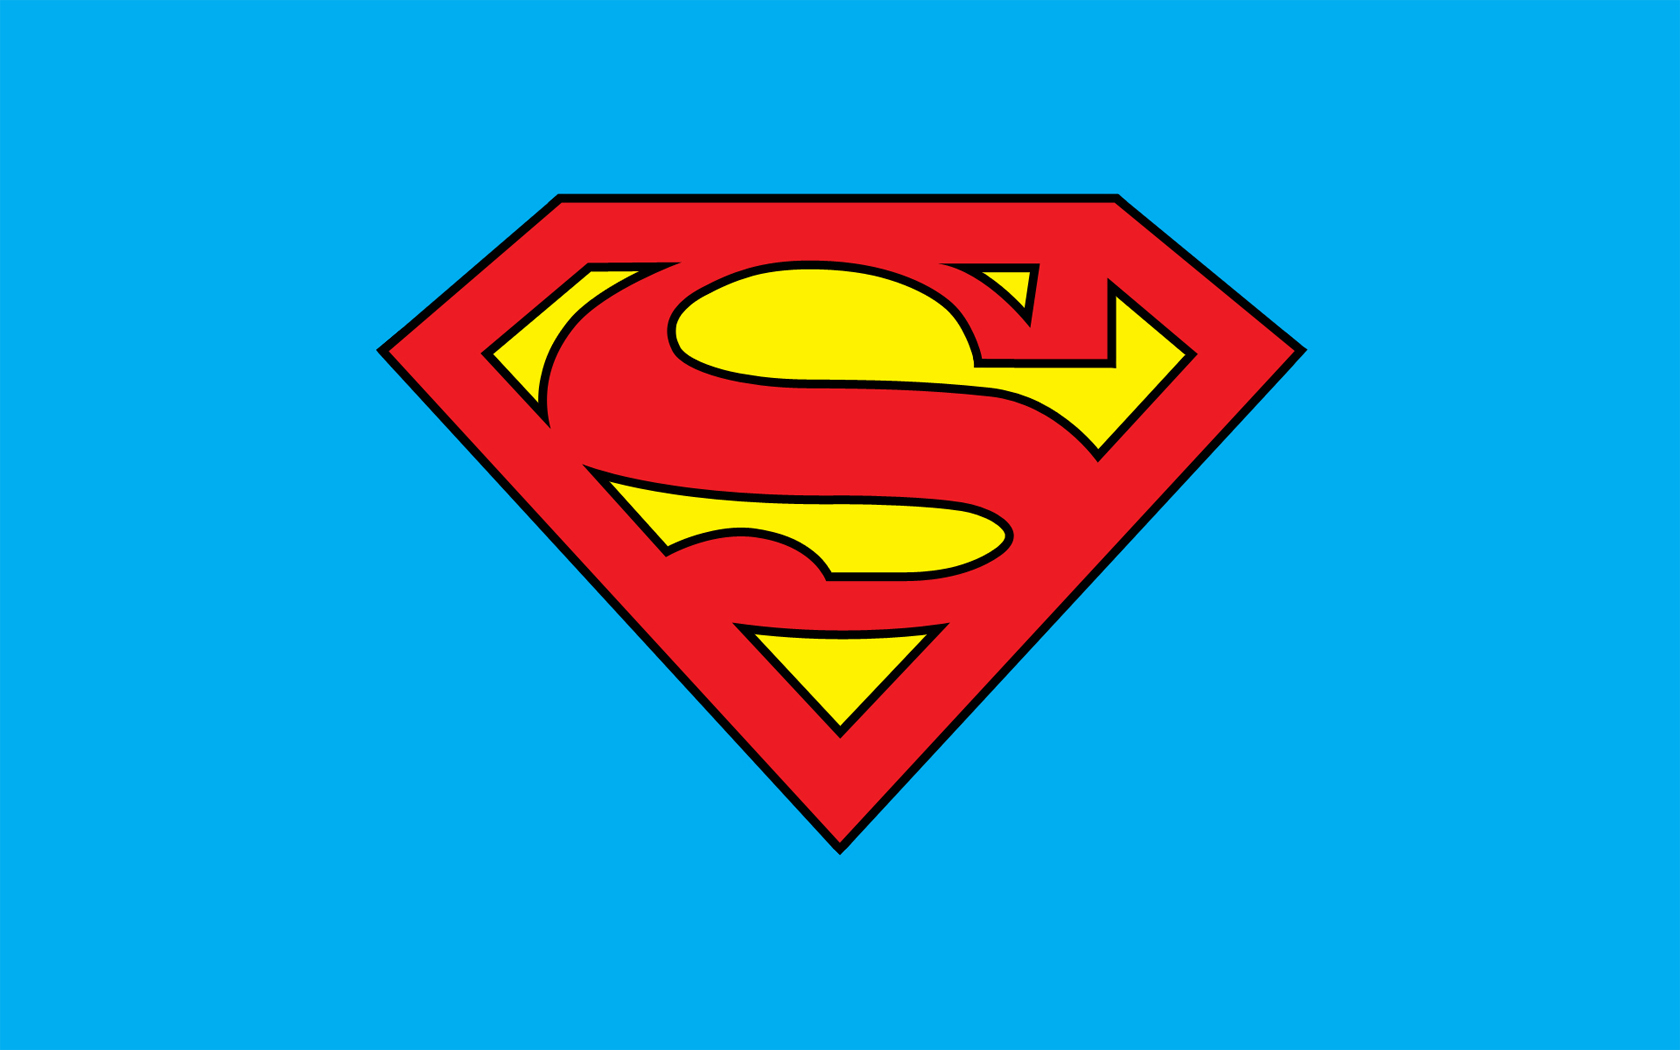

In [11]:
#Display the image
display(img)

###2. Display only the top left corner of 100x100 pixels.


*  Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and Array Indexing


In [12]:
import numpy as np
import matplotlib.pyplot as plt

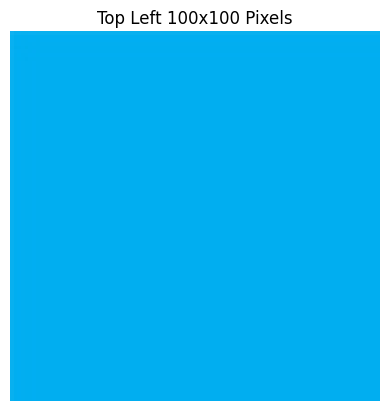

In [13]:

# Convert image to NumPy array
img_array = np.array(img)

# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

# Display the cropped image
plt.imshow(top_left)
plt.axis('off')
plt.title("Top Left 100x100 Pixels")
plt.show()

###3. Show the three color channels (R, G, B).


*   Separate the image into its three color channels (Red, Green, and Blue) and display them individually, labeling each channel as R, G, and B.{Using NumPy.}

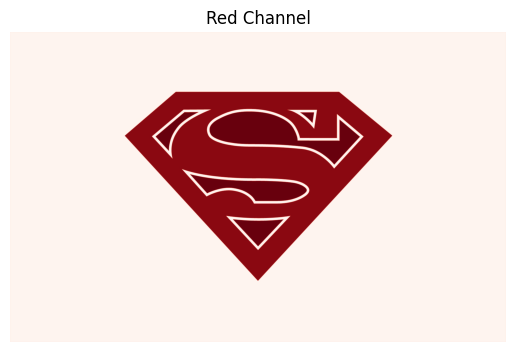

In [14]:
R = img_array[:, :, 0]

plt.figure()
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")
plt.show()

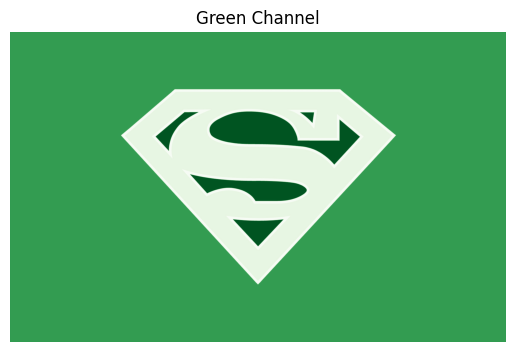

In [15]:
G = img_array[:, :, 1]

plt.figure()
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")
plt.show()

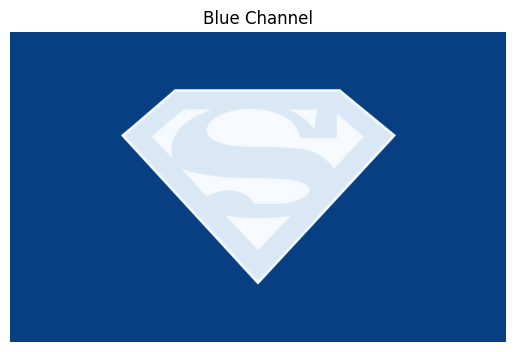

In [16]:
B = img_array[:, :, 2]

plt.figure()
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")
plt.show()

###4. Modify the top 100 ×100 pixels to a value of 210 and display the resulting image:
* Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a light gray color), and then display the modified image.

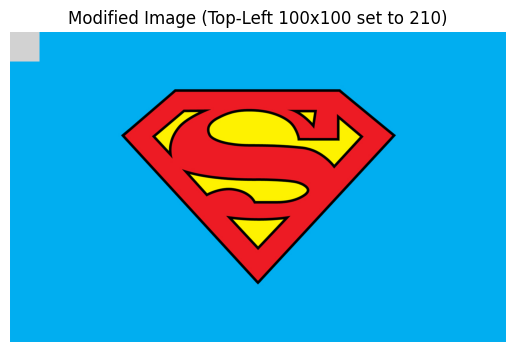

In [17]:
# Convert to NumPy array
img_array = np.array(img)

# Modify top-left 100x100 pixels to 210 (light gray)
img_array[0:100, 0:100] = 210

# Display modified image
plt.imshow(img_array)
plt.axis('off')
plt.title("Modified Image (Top-Left 100x100 set to 210)")
plt.show()

##2.2 Exercise- 2:



###1. Load and display a grayscale image.
* Load a grayscale image using the Pillow library.
* Display the grayscale image using matplotlib.

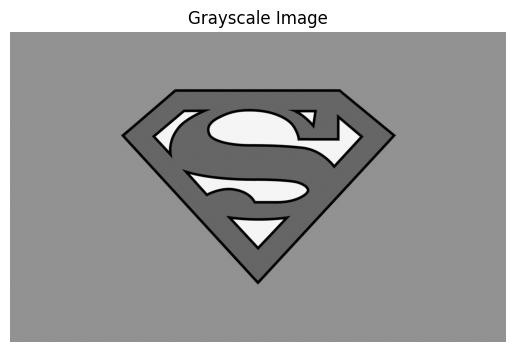

In [19]:
gray_img = img.convert("L")
gray_array = np.array(gray_img)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

###2. Extract and display the middle section of the image (150 pixels).
* Extract a 150 pixel section from the center of the image using NumPy array slicing.
* Display this cropped image using matplotlib.

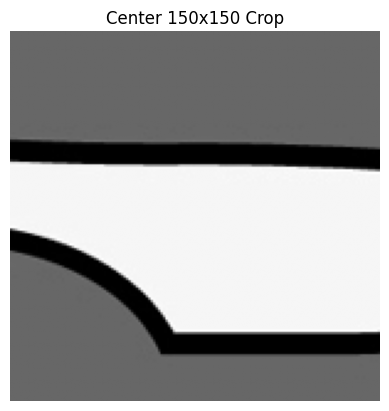

In [20]:
h, w = gray_array.shape

center_crop = gray_array[h//2 - 75 : h//2 + 75,
                         w//2 - 75 : w//2 + 75]

plt.imshow(center_crop, cmap="gray")
plt.title("Center 150x150 Crop")
plt.axis("off")
plt.show()

###3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
* Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
* Display the resulting binary image.

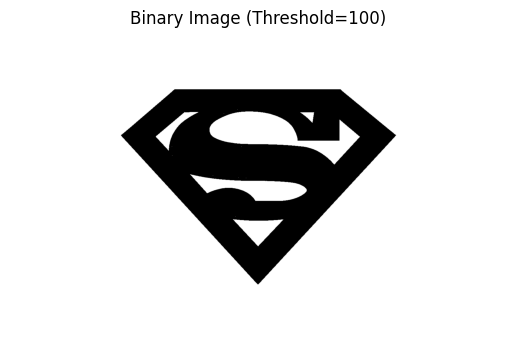

In [21]:
binary_img = gray_array.copy()

binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

plt.imshow(binary_img, cmap="gray")
plt.title("Binary Image (Threshold=100)")
plt.axis("off")
plt.show()

###4. Rotate the image 90 degrees clockwise and display the result.
* Rotatethe image by90degrees clockwise using the Pillow rotate method or by manipulating
the image array.
* Display the rotated image using matplotlib

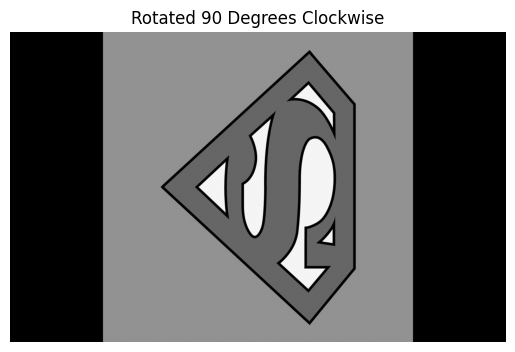

In [22]:
rotated = gray_img.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

###5. Convert the grayscale image to an RGB image.
* Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
* Display the converted RGB image using matplotlib

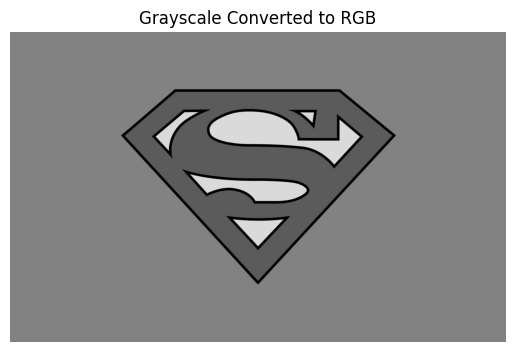

In [23]:
rgb_from_gray = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_from_gray)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

## 3. Image Compression and Decompression using PCA.
In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice**

###1. Load and Prepare Data:
* Fetch an image of you choice.{If colour convert to grayscale}
* Center the dataset- Standaridze the Data.
* Calculate the covaraince matrix of the Standaridze data.

In [24]:
# Load image and convert to grayscale
img_array = np.array(gray_img, dtype=np.float64)

# Center the data
mean = np.mean(img_array, axis=0)
centered_data = img_array - mean

In [25]:
cov_matrix = np.cov(centered_data, rowvar=False)

###2. Eigen Decomposition and Identifying Principal Components:
Compute Eigen Values and Eigen Vectors.
* Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
* Identify the Principal Components with the help of cumulative Sum plot.

In [26]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
sorted_index = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

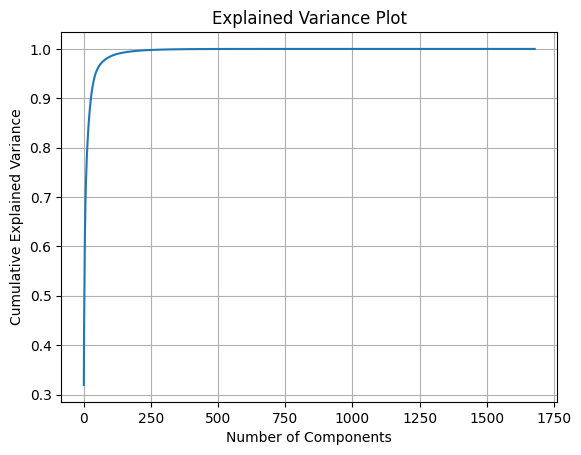

In [27]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

###3. Reconstruction and Experiment:
* Reconstruction: Transform the original data by multiplying it with the selected eigenvec
tors(PCs) to obtain a lower-dimensional representation.
* Experiments: Pick Four different combination of principal components with various ex
plained variance value and compare the result.
* Display the Results and Evaluate.

In [28]:
def reconstruct_image(k):
    pcs = eigenvectors[:, :k]
    reduced = np.dot(centered_data, pcs)
    reconstructed = np.dot(reduced, pcs.T) + mean
    return reconstructed

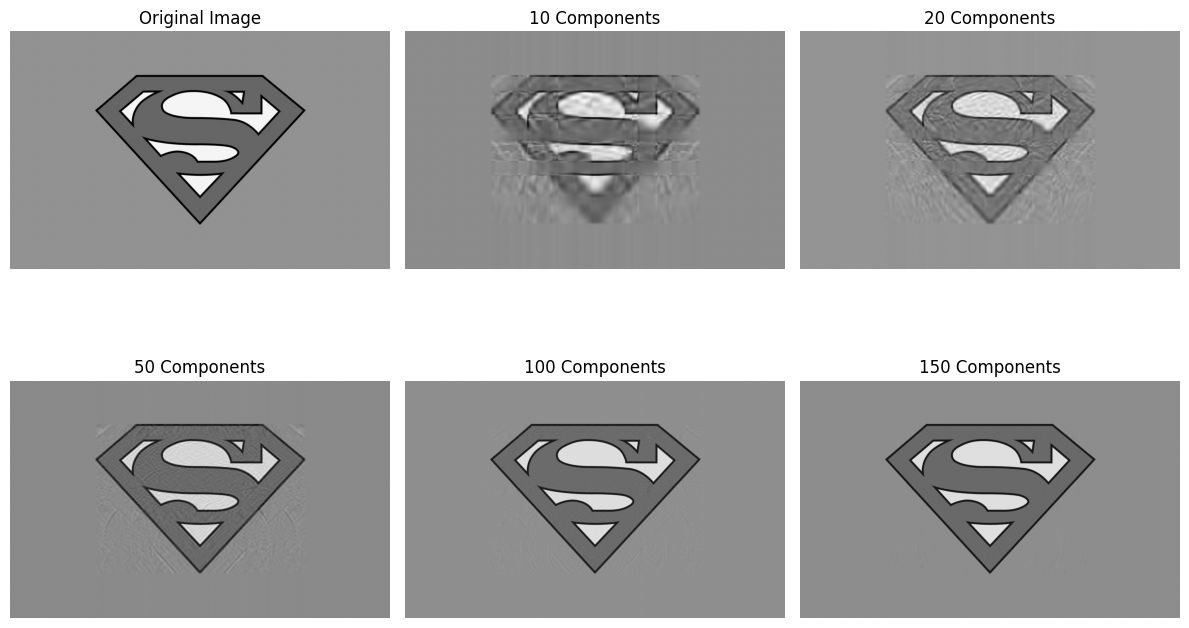

In [29]:
k_values = [10, 20, 50, 100, 150]

plt.figure(figsize=(12,8))

# Show Original Image
plt.subplot(2,3,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Show PCA Reconstructions
for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(k)

    plt.subplot(2,3,i+2)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()